# Лабораторна робота №2
## Методи інтелектуальної обробки даних
### Тема: Візуалізація даних із використанням мови Python

**Датасет:** NIAAA Apparent Per Capita Alcohol Consumption, 1977–2023  
**Джерело:** National Institute on Alcohol Abuse and Alcoholism (NIAAA)  
**Опис:** Набір містить дані про споживання алкоголю на душу населення по штатах США з 1977 по 2023 рік. Для кожного штату та року представлені показники споживання пива, вина та міцних напоїв у галонах чистого етанолу, а також перерахунок у кількість стандартних напоїв.

---
## Завдання 1. Підготовка набору даних

### 1.1 Завантаження набору даних

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Налаштування стилю
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Завантаження датасету (покладіть файл поряд із ноутбуком)
df = pd.read_csv('niaaa_apparent_per_capita_consumption_1977_2023.csv')

print('Розмір датасету:', df.shape)
print('Роки:', df['year'].min(), '–', df['year'].max())
print('Штатів (включно з US):', df['state'].nunique())
df.head(10)

Розмір датасету: (2632, 11)
Роки: 1977 – 2023
Штатів (включно з US): 56


,state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
0,alabama,Alabama,1977,0.97,0.12,0.82,1.92,229.9259,23.8140,170.2514,409.6000
1,alabama,Alabama,1978,0.95,0.12,0.85,1.92,225.1852,23.8140,176.4801,409.6000
2,alabama,Alabama,1979,0.96,0.12,0.82,1.90,227.5556,23.8140,170.2514,405.3333
3,alabama,Alabama,1980,0.95,0.16,0.74,1.86,225.1852,31.7519,153.6415,396.8000
4,alabama,Alabama,1981,1.00,0.19,0.73,1.91,237.0370,37.7054,151.5653,407.4667
5,alabama,Alabama,1982,1.00,0.18,0.72,1.90,237.0370,35.7209,149.4891,405.3333
6,alabama,Alabama,1983,1.01,0.17,0.72,1.90,239.4074,33.7364,149.4891,405.3333
7,alabama,Alabama,1984,1.03,0.19,0.69,1.91,244.1481,37.7054,143.2603,407.4667
8,alabama,Alabama,1985,1.07,0.17,0.67,1.92,253.6296,33.7364,139.1079,409.6000
9,alabama,Alabama,1986,1.10,0.18,0.65,1.92,260.7407,35.7209,134.9554,409.6000


> **Структура датасету:** 2 632 рядки × 11 ознак.
>
> | Ознака | Тип | Опис |
> |---|---|---|
> | `state` | текст | Назва штату (нижній регістр) |
> | `state_name` | текст | Повна назва штату |
> | `year` | числовий | Рік спостереження (1977–2023) |
> | `ethanol_beer_gallons_per_capita` | числовий | Споживання пива (галони ет./душу нас.) |
> | `ethanol_wine_gallons_per_capita` | числовий | Споживання вина |
> | `ethanol_spirit_gallons_per_capita` | числовий | Споживання міцних напоїв |
> | `ethanol_all_drinks_gallons_per_capita` | числовий | Загальне споживання |
> | `number_of_beers` | числовий | Кількість стандартних банок пива |
> | `number_of_glasses_wine` | числовий | Кількість стандартних келихів вина |
> | `number_of_shots_liquor` | числовий | Кількість стандартних шотів |
> | `number_of_drinks_total` | числовий | Загальна кількість стандартних напоїв |
>
> Текстових ознак: 2 (`state` – назва штату в нижньому регістрі, `state_name` – відформатована назва). Числових ознак: 8. Порядкова ознака `year` забезпечує хронологічний порядок.

### 1.2 Базова підготовка даних

In [15]:
# Типи даних
print('Типи даних:')
print(df.dtypes)
print()

# Пропуски
print('Пропущені значення:')
print(df.isnull().sum())

Типи даних:
state                                        str
state_name                                   str
year                                       int64
ethanol_beer_gallons_per_capita          float64
ethanol_wine_gallons_per_capita          float64
ethanol_spirit_gallons_per_capita        float64
ethanol_all_drinks_gallons_per_capita    float64
number_of_beers                          float64
number_of_glasses_wine                   float64
number_of_shots_liquor                   float64
number_of_drinks_total                   float64
dtype: object

Пропущені значення:
state                                    0
state_name                               0
year                                     0
ethanol_beer_gallons_per_capita          0
ethanol_wine_gallons_per_capita          0
ethanol_spirit_gallons_per_capita        0
ethanol_all_drinks_gallons_per_capita    0
number_of_beers                          0
number_of_glasses_wine                   0
number_of_shots_liquor     

In [ ]:
# Базова описова статистика
df.describe().round(3)

In [ ]:
# Унікальні коди штатів
print('Коди штатів:', sorted(df['state'].unique()))

In [ ]:
# Підготовка: виокремлюємо загальнонаціональний запис 'us total'
df_states = df[df['state'] != 'us total'].copy()   # 55 штатів + DC
df_us     = df[df['state'] == 'us total'].copy()   # США загалом – для тренду

# Перевірка аномалій (значення > 99-го перцентиля)
q99 = df_states['ethanol_all_drinks_gallons_per_capita'].quantile(0.99)
outliers = df_states[df_states['ethanol_all_drinks_gallons_per_capita'] > q99]
print(f'99-й перцентиль: {q99:.2f} гал.')
print(f'Значень вище 99-го перцентиля: {len(outliers)}')
print(outliers[['state_name','year','ethanol_all_drinks_gallons_per_capita']].to_string(index=False))

print(f'\nДатасет по штатах: {df_states.shape}')
print(f'Загальнонаціональні дані (us): {df_us.shape}')

**Висновок щодо підготовки:** Датасет не містить жодних пропущених значень. Усі числові колонки мають коректний тип `float64`, `year` – `int64`, текстові – `object`. Запис `'us total'` виокремлено для аналізу загальнонаціонального тренду – він є агрегованим і не є окремим штатом. Аномально високі значення належать штату Nevada у ранні роки – це реальний феномен туристичної індустрії, тому записи не видаляємо, але враховуємо при інтерпретації.

---
## Завдання 2. Візуальний аналіз даних

### 2.1 Розподіл однієї змінної – гістограма та KDE

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Ліво: гістограма + KDE для загального споживання ---
ax1 = axes[0]
data_all = df_states['ethanol_all_drinks_gallons_per_capita'].dropna()

ax1.hist(
    data_all, bins=30,
    color='#3a7dbf', edgecolor='white', alpha=0.82,
    density=True, label='Гістограма'
)
kde = gaussian_kde(data_all)
x_range = np.linspace(data_all.min(), data_all.max(), 300)
ax1.plot(x_range, kde(x_range), color='#1a3a6b', linewidth=2.5, label='KDE')
ax1.axvline(data_all.mean(), color='#e07b54', linewidth=2,
            linestyle='--', label=f'Середнє: {data_all.mean():.2f}')
ax1.axvline(data_all.median(), color='#59a14f', linewidth=2,
            linestyle=':', label=f'Медіана: {data_all.median():.2f}')
ax1.set_title('Розподіл загального споживання алкоголю\n(усі штати, 1977–2023)', fontweight='bold')
ax1.set_xlabel('Галони чистого етанолу на душу нас./рік')
ax1.set_ylabel('Щільність')
ax1.legend(fontsize=9)

# --- Право: гістограми по десятиліттях ---
ax2 = axes[1]
decades = [
    ('1977–1989', (1977, 1989), '#e15759'),
    ('1990–1999', (1990, 1999), '#f28e2b'),
    ('2000–2009', (2000, 2009), '#4e79a7'),
    ('2010–2023', (2010, 2023), '#59a14f'),
]
for label, (y_from, y_to), color in decades:
    d = df_states[
        (df_states['year'] >= y_from) & (df_states['year'] <= y_to)
    ]['ethanol_all_drinks_gallons_per_capita']
    ax2.hist(d, bins=22, alpha=0.55, color=color,
             edgecolor='white', label=label, density=True)

ax2.set_title('Розподіл споживання за десятиліттями\n(групування по роках)', fontweight='bold')
ax2.set_xlabel('Галони чистого етанолу на душу нас./рік')
ax2.set_ylabel('Щільність')
ax2.legend(title='Період', fontsize=9)

plt.tight_layout()
plt.savefig('plot_2_1.png', bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

**Висновок:** Розподіл загального споживання алкоголю є правосторонньо скошеним – більшість штатів споживає 1.5–3.0 галони чистого етанолу на рік, проте є хвіст праворуч (Nevada). Середнє перевищує медіану, що підтверджує асиметрію. Порівняння по десятиліттях виявляє чіткий зсув ліворуч: у 1977–1989 пік розподілу знаходився значно правіше, ніж у 2010–2023, що свідчить про загальне зниження споживання алкоголю у США.

### 2.2 Порівняння категорій – стовпчикова діаграма

In [ ]:
# Середнє споживання трьох видів алкоголю – Топ-15 штатів
top15_states = (
    df_states.groupby('state_name')['ethanol_all_drinks_gallons_per_capita']
    .mean().nlargest(15).index.tolist()
)
df_top15 = df_states[df_states['state_name'].isin(top15_states)]
grouped = df_top15.groupby('state_name')[[
    'ethanol_beer_gallons_per_capita',
    'ethanol_wine_gallons_per_capita',
    'ethanol_spirit_gallons_per_capita'
]].mean().round(3)
grouped.columns = ['Пиво', 'Вино', 'Міцні напої']
grouped = grouped.loc[grouped.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(grouped))
width = 0.27
bar_colors = ['#e07b54', '#7ab87a', '#5c8db8']

for i, (col, color) in enumerate(zip(grouped.columns, bar_colors)):
    bars = ax.bar(x + i * width, grouped[col], width,
                  label=col, color=color, edgecolor='white', alpha=0.92)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_title('Середнє споживання за видами алкоголю – Топ-15 штатів США (1977–2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Штат')
ax.set_ylabel('Галони чистого етанолу на душу нас./рік')
ax.set_xticks(x + width)
ax.set_xticklabels(grouped.index, rotation=35, ha='right', fontsize=9)
ax.legend(title='Вид напою')
ax.set_ylim(0, grouped.values.max() * 1.22)

plt.tight_layout()
plt.savefig('plot_2_2.png', bbox_inches='tight')
plt.show()

**Висновок:** New Hampshire очолює рейтинг за середнім споживанням за весь період 1977–2023 – завдяки особливостям державної системи продажу алкоголю без акцизу, що приваблює покупців із сусідніх штатів. Nevada, попри стереотип «лідера», не потрапила до топ-15 за середнім: у ранні роки споживання там було аномально високим через туризм, однак з часом суттєво знизилось, що зменшило середнє за весь період. У більшості штатів-лідерів домінує пиво. District of Columbia вирізняється непропорційно високою часткою вина – що відображає демографію та доходи населення столиці.

### 2.3 Аналіз розкиду та викидів – ящик з вусами

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Ліво: box plot по видах алкоголю (дані 2023 року) ---
ax1 = axes[0]
df_2023 = df_states[df_states['year'] == 2023]
data_to_plot = [
    df_2023['ethanol_beer_gallons_per_capita'].dropna(),
    df_2023['ethanol_wine_gallons_per_capita'].dropna(),
    df_2023['ethanol_spirit_gallons_per_capita'].dropna(),
    df_2023['ethanol_all_drinks_gallons_per_capita'].dropna(),
]
labels_box = ['Пиво', 'Вино', 'Міцні напої', 'Всього']
bp = ax1.boxplot(
    data_to_plot, labels=labels_box,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.2),
    flierprops=dict(marker='o', markersize=6, markerfacecolor='gray', alpha=0.5)
)
for patch, color in zip(bp['boxes'], ['#e07b54','#7ab87a','#5c8db8','#b07aa1']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax1.set_title('Розподіл споживання за видами напоїв\nпо штатах США (2023)', fontweight='bold')
ax1.set_ylabel('Галони чистого етанолу на душу нас./рік')
ax1.set_xlabel('Вид напою')

# --- Право: box plot загального споживання по декадах ---
ax2 = axes[1]
df_dec = df_states.copy()
df_dec['decade'] = pd.cut(df_dec['year'],
    bins=[1976, 1989, 1999, 2009, 2023],
    labels=['1977–1989','1990–1999','2000–2009','2010–2023'])

sns.boxplot(
    data=df_dec,
    x='decade', y='ethanol_all_drinks_gallons_per_capita',
    order=['1977–1989','1990–1999','2000–2009','2010–2023'],
    palette=['#e15759','#f28e2b','#4e79a7','#59a14f'],
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    linewidth=1.5, ax=ax2
)
ax2.set_title('Розподіл загального споживання\nза десятиліттями (всі штати)', fontweight='bold')
ax2.set_xlabel('Період')
ax2.set_ylabel('Галони чистого етанолу на душу нас./рік')

# Підписи медіан
for i, decade in enumerate(['1977–1989','1990–1999','2000–2009','2010–2023']):
    med = df_dec[df_dec['decade'] == decade]['ethanol_all_drinks_gallons_per_capita'].median()
    ax2.text(i, med + 0.05, f'{med:.2f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#222')

plt.tight_layout()
plt.savefig('plot_2_3.png', bbox_inches='tight')
plt.show()

**Висновок:** У розрізі видів напоїв (2023) пиво та вино мають компактні ящики – штати досить однорідні між собою. Міцні напої мають помітно більший розкид між штатами. Викид вгору у категорії «Всього» (~4.2) відповідає штату з аномально високим загальним споживанням. У розрізі десятиліть споживання не знижувалось монотонно: медіана впала з 2.61 у 1977–1989 до мінімуму 2.24 у 1990–1999, після чого почала зростати – 2.30 у 2000–2009 і 2.38 у 2010–2023. Це свідчить про те, що США пройшли через мінімум у 1990-х, а далі споживання поступово відновлювалось. Розкид між штатами з часом звужується – штати стають більш однорідними.

### 2.4 Структура та пропорції – кільцева діаграма

In [ ]:
# Порівнюємо структуру споживання: перші роки спостережень vs останні
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

periods = [
    ('1977–1985', (1977, 1985), axes[0]),
    ('2015–2023', (2015, 2023), axes[1]),
]
donut_colors = ['#e07b54', '#7ab87a', '#5c8db8']
drink_labels = ['Пиво', 'Вино', 'Міцні напої']
drink_cols = [
    'ethanol_beer_gallons_per_capita',
    'ethanol_wine_gallons_per_capita',
    'ethanol_spirit_gallons_per_capita'
]

for period_label, (y_from, y_to), ax in periods:
    subset = df_states[(df_states['year'] >= y_from) & (df_states['year'] <= y_to)]
    values = [subset[col].mean() for col in drink_cols]

    wedges, texts, autotexts = ax.pie(
        values, labels=drink_labels,
        colors=donut_colors,
        autopct='%1.1f%%', pctdistance=0.78,
        startangle=120, explode=(0.04, 0.04, 0.04),
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
    )
    for t in texts:
        t.set_fontsize(11); t.set_fontweight('bold')
    for at in autotexts:
        at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')

    total = sum(values)
    ax.text(0, 0, f'{period_label}\n{total:.2f} гал.',
            ha='center', va='center', fontsize=10, fontweight='bold', color='#333')
    ax.set_title(f'Структура споживання\n{period_label}', fontsize=12, fontweight='bold')

fig.suptitle('Зміна структури споживання алкоголю в США:\nпочаток спостережень vs останні роки',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_2_4.png', bbox_inches='tight')
plt.show()

**Висновок:** Структура споживання алкоголю в США не надто суттєво змінилась за 40 років. У 1977–1985 роках пиво становило ~49.6% обсягу, вино – 11.7%, міцні напої – 38.7%. У 2015–2023 частка пива скоротилась до 43.5%, натомість вино зросло до 16.8%, а міцні напої – до 39.7%, що свідчить про зміну смакових уподобань американців на користь вина та різноманітніших напоїв. Загальний обсяг споживання при цьому знизився з 2.77 до 2.52 галона.

### 2.5 Взаємозв'язок двох числових змінних – точкова діаграма

In [ ]:
# Scatter: пиво vs міцні напої
# Колір = декада, розмір точки = загальне споживання

df_scatter = df_states.copy()
df_scatter['decade'] = pd.cut(df_scatter['year'],
    bins=[1976, 1989, 1999, 2009, 2023],
    labels=['1977–1989','1990–1999','2000–2009','2010–2023'])

palette_sc = {
    '1977–1989': '#e15759', '1990–1999': '#f28e2b',
    '2000–2009': '#4e79a7', '2010–2023': '#59a14f'
}

fig, ax = plt.subplots(figsize=(11, 7))

for decade, group in df_scatter.groupby('decade', observed=True):
    ax.scatter(
        group['ethanol_beer_gallons_per_capita'],
        group['ethanol_spirit_gallons_per_capita'],
        c=palette_sc[decade],
        s=group['ethanol_all_drinks_gallons_per_capita'] * 12,
        alpha=0.40, edgecolors='white', linewidth=0.4, label=decade
    )

# Лінія тренду
x_v = df_scatter['ethanol_beer_gallons_per_capita'].values
y_v = df_scatter['ethanol_spirit_gallons_per_capita'].values
mask = ~(np.isnan(x_v) | np.isnan(y_v))
z = np.polyfit(x_v[mask], y_v[mask], 1)
x_line = np.linspace(x_v[mask].min(), x_v[mask].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.5, alpha=0.55, label='Лінія тренду')

corr = np.corrcoef(x_v[mask], y_v[mask])[0, 1]
ax.set_title(f'Залежність між споживанням пива та міцних напоїв\n'
             f'(r = {corr:.2f}, розмір точки = загальне споживання)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Пиво (галони ет./душу нас./рік)')
ax.set_ylabel('Міцні напої (галони ет./душу нас./рік)')
ax.legend(title='Декада', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plot_2_5.png', bbox_inches='tight')
plt.show()
print(f'Кореляція Пірсона: {corr:.3f}')

**Висновок:** Між споживанням пива та міцних напоїв існує помірна позитивна кореляція. Штати з вищим пивним споживанням мають тенденцію до вищого споживання міцного, хоча залежність далека від лінійної. Кольорове розмежування по декадах наочно показує «зрушення» хмари точок у нижній лівий кут з часом – загальне зниження споживання обох видів. Найбільші точки (Nevada у ранні роки) виразно виділяються як аномалія.

### 2.6 Динаміка та тренд – лінійний графік

In [ ]:
# Загальнонаціональний тренд + 4 виділені штати
highlight_states = {
    'nevada':              ('Nevada',        '#e15759'),
    'utah':                ('Utah',          '#59a14f'),
    'new hampshire':       ('New Hampshire', '#4e79a7'),
    'district of columbia':('DC',            '#b07aa1'),
}

fig, ax = plt.subplots(figsize=(13, 6))

# США загалом
us_trend = df_us.sort_values('year').groupby('year')['ethanol_all_drinks_gallons_per_capita'].mean()
ax.plot(us_trend.index, us_trend.values, color='black', linewidth=2.8,
        zorder=5, label='США (загалом)')
ax.fill_between(us_trend.index, us_trend.values, alpha=0.07, color='black')

# Виділені штати
for state_code, (label, color) in highlight_states.items():
    s = df_states[df_states['state'] == state_code].sort_values('year')
    ax.plot(s['year'], s['ethanol_all_drinks_gallons_per_capita'],
            color=color, linewidth=1.8, alpha=0.88, label=label)

# Фонові смуги по декадах
for (d_start, d_end), bg in zip(
        [(1977,1989),(1990,1999),(2000,2009),(2010,2023)],
        ['#f0f4ff','#fff9f0','#f0f9f0','#fff0f0']):
    ax.axvspan(d_start, d_end, alpha=0.28, color=bg, zorder=0)

ax.set_title('Динаміка споживання алкоголю в США (1977–2023)\n'
             'Загальнонаціональний тренд та окремі штати',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Рік')
ax.set_ylabel('Галони чистого етанолу на душу нас./рік')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.set_xlim(1977, 2023)
ax.legend(title='Штат', loc='upper right')

plt.tight_layout()
plt.savefig('plot_2_6.png', bbox_inches='tight')
plt.show()

**Висновок:** Загальнонаціональний тренд чітко ілюструє три фази: зростання до початку 1980-х, поступове зниження до кінця 1990-х, і відносна стабілізація на рівні ~2.0–2.3 галони у 2000–2023. Utah стабільно тримається найнижче серед усіх штатів (вплив мормонської культури). Nevada – незмінний лідер через туризм, але її показники значно знизились після 1980-х. New Hampshire стабільно вища за середнє. DC у пізні роки наближається до New Hampshire через демографію та зростаючу популярність вина і крафтових напоїв.

### 2.7 Матриця кореляцій – теплова карта

In [ ]:
corr_cols = [
    'ethanol_beer_gallons_per_capita',
    'ethanol_wine_gallons_per_capita',
    'ethanol_spirit_gallons_per_capita',
    'ethanol_all_drinks_gallons_per_capita',
    'number_of_beers',
    'number_of_glasses_wine',
    'number_of_shots_liquor',
    'number_of_drinks_total'
]
corr_labels = [
    'Пиво (гал.)', 'Вино (гал.)', 'Міцні (гал.)', 'Всього (гал.)',
    'Банок пива', 'Келихів вина', 'Шотів', 'Напоїв всього'
]

corr_matrix = df_states[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Коефіцієнт кореляції Пірсона'},
    ax=ax
)
ax.set_title('Матриця кореляцій числових змінних (NIAAA датасет)',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plot_2_7.png', bbox_inches='tight')
plt.show()

**Висновок:** Галонні показники та кількісні (банок/келихів/шотів) мають кореляцію 1.0 у межах одного виду – закономірно, оскільки вони є лінійним перерахунком одне одного. Між різними видами алкоголю зв'язок помірний: вино та міцні напої мають найвищу кореляцію між різними категоріями (\~0.55–0.60) – це вказує, що «непивна» культура споживання є більш монолітною. Пиво має нижчу кореляцію з іншими видами, що підтверджує його відокремлену культуру споживання. Загальний показник найбільше корелює з пивом (~0.87) – оскільки пиво домінує в обсязі.

### 2.8 Комбінований графік – дашборд

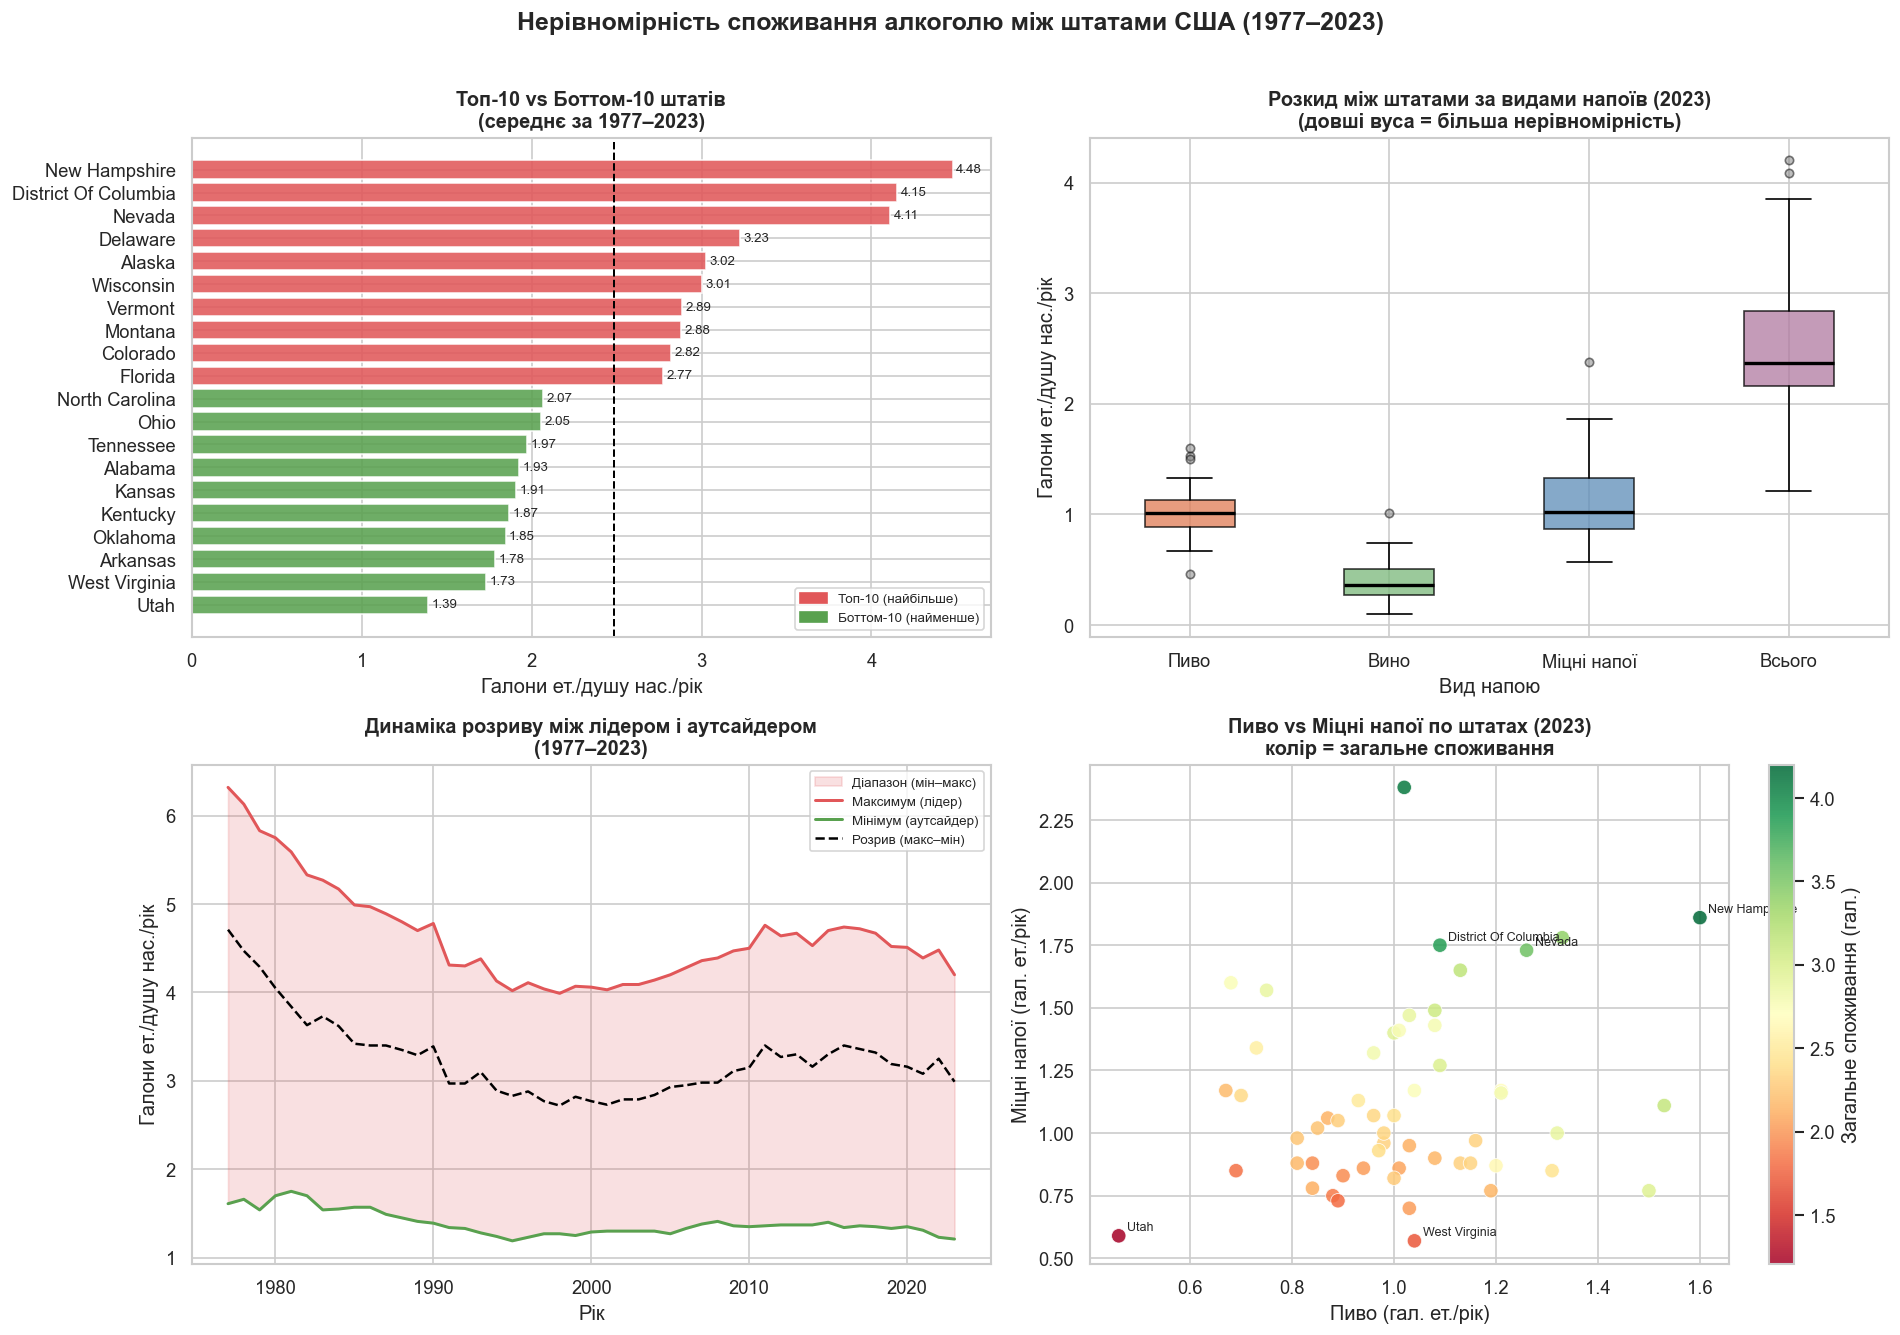

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Нерівномірність споживання алкоголю між штатами США (1977–2023)',
             fontsize=15, fontweight='bold', y=1.01)

# -- Графік 1 (верх-ліво): Топ-10 vs Боттом-10 штатів --
ax1 = axes[0, 0]
state_avg = (
    df_states.groupby('state_name')['ethanol_all_drinks_gallons_per_capita']
    .mean().sort_values()
)
bot10 = state_avg.head(10)
top10 = state_avg.tail(10)
combined = pd.concat([bot10, top10])
bar_clrs = ['#59a14f'] * 10 + ['#e15759'] * 10
ax1.barh(combined.index, combined.values, color=bar_clrs, edgecolor='white', alpha=0.87)
ax1.axvline(state_avg.mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Середнє: {state_avg.mean():.2f}')
for i, (name, val) in enumerate(combined.items()):
    ax1.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=8)
ax1.set_title('Топ-10 vs Боттом-10 штатів\n(середнє за 1977–2023)', fontweight='bold')
ax1.set_xlabel('Галони ет./душу нас./рік')
ax1.legend(handles=[
    Patch(color='#e15759', label='Топ-10 (найбільше)'),
    Patch(color='#59a14f', label='Боттом-10 (найменше)'),
], fontsize=8, loc='lower right')

# -- Графік 2 (верх-право): Розкид між штатами по видах напоїв --
ax2 = axes[0, 1]
df_2023 = df_states[df_states['year'] == 2023]
data_bp = [
    df_2023['ethanol_beer_gallons_per_capita'].dropna(),
    df_2023['ethanol_wine_gallons_per_capita'].dropna(),
    df_2023['ethanol_spirit_gallons_per_capita'].dropna(),
    df_2023['ethanol_all_drinks_gallons_per_capita'].dropna(),
]
bp = ax2.boxplot(
    data_bp, labels=['Пиво', 'Вино', 'Міцні напої', 'Всього'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='gray', alpha=0.5)
)
for patch, color in zip(bp['boxes'], ['#e07b54', '#7ab87a', '#5c8db8', '#b07aa1']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_title('Розкид між штатами за видами напоїв (2023)\n(довші вуса = більша нерівномірність)', fontweight='bold')
ax2.set_ylabel('Галони ет./душу нас./рік')
ax2.set_xlabel('Вид напою')

# -- Графік 3 (низ-ліво): Динаміка розриву між лідером і аутсайдером --
ax3 = axes[1, 0]
gap_data = df_states.groupby('year')['ethanol_all_drinks_gallons_per_capita'].agg(['max', 'min'])
ax3.fill_between(gap_data.index, gap_data['min'], gap_data['max'],
                 alpha=0.18, color='#e15759', label='Діапазон (мін–макс)')
ax3.plot(gap_data.index, gap_data['max'], color='#e15759', linewidth=1.8, label='Максимум (лідер)')
ax3.plot(gap_data.index, gap_data['min'], color='#59a14f', linewidth=1.8, label='Мінімум (аутсайдер)')
ax3.plot(gap_data.index, gap_data['max'] - gap_data['min'],
         color='black', linewidth=1.5, linestyle='--', label='Розрив (макс–мін)')
ax3.set_title('Динаміка розриву між лідером і аутсайдером\n(1977–2023)', fontweight='bold')
ax3.set_xlabel('Рік')
ax3.set_ylabel('Галони ет./душу нас./рік')
ax3.legend(fontsize=8)
ax3.xaxis.set_major_locator(mticker.MultipleLocator(10))

# -- Графік 4 (низ-право): Scatter кожен штат (2023) --
ax4 = axes[1, 1]
sc = ax4.scatter(
    df_2023['ethanol_beer_gallons_per_capita'],
    df_2023['ethanol_spirit_gallons_per_capita'],
    c=df_2023['ethanol_all_drinks_gallons_per_capita'],
    cmap='RdYlGn', s=75, alpha=0.85,
    edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax4, label='Загальне споживання (гал.)')
for _, row in df_2023.iterrows():
    if row['state'] in ['new hampshire', 'utah', 'nevada', 'district of columbia', 'west virginia']:
        ax4.annotate(
            row['state_name'],
            xy=(row['ethanol_beer_gallons_per_capita'],
                row['ethanol_spirit_gallons_per_capita']),
            fontsize=7.5, xytext=(5, 3), textcoords='offset points'
        )
ax4.set_title('Пиво vs Міцні напої по штатах (2023)\nколір = загальне споживання', fontweight='bold')
ax4.set_xlabel('Пиво (гал. ет./рік)')
ax4.set_ylabel('Міцні напої (гал. ет./рік)')

plt.tight_layout()
plt.savefig('plot_2_8.png', bbox_inches='tight')
plt.show()

**Висновок:** Дашборд з чотирьох кутів розкриває проблему нерівномірності споживання алкоголю між штатами США. Рейтинг (верх-ліво) показує, що New Hampshire споживає майже втричі більше за Utah – найбільший розрив серед усіх штатів. Box plot (верх-право) демонструє, що найбільша нерівномірність спостерігається у загальному показнику та міцних напоях – вино має найкомпактніший розподіл між штатами. Динамічний графік (низ-ліво) показує, що розрив між лідером і аутсайдером скорочувався з кінця 1970-х до 1990-х, але відтоді залишається стабільно значним. Scatter (низ-право) виявляє, що переважна більшість штатів утворює компактний кластер у нижньому лівому куті, тоді як New Hampshire та Nevada чітко виділяються як аномалії з аномально високим рівнем споживання.